# Comparison of the SSR setups against the CSR baseline setup (shared dependencies)

This covers all three setups, and analyses the difference in performance. Since the CSR and SSRH setup allow the possibility to share dependencies, these setups use that variant.

In [3]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

path = '../../../../playwright/results/core-web-vitals/testrun-9/'

pd.set_option('display.float_format', lambda x: '%.2f' % x)
plt.rcParams.update({'font.size': 14})

features = ['navTime', 'totalTime', 'lcp', 'fcp', 'ttfb', 'tbt', 'tti', 'longestTask', 'longTasks', 'nf:init', 'nf:config', 'nf:loaded']

def detect_outliers(df, features, contamination=0.1):
    clf = IsolationForest(contamination=contamination, random_state=42)
    outliers = clf.fit_predict(df[features])
    return outliers == 1

def bootstrap_ci(data1, data2, n_iterations=5000, ci=0.99):
    rng = np.random.default_rng(42)
    diffs = []
    
    for _ in range(n_iterations):
        boot1 = rng.choice(data1, size=len(data1), replace=True)
        boot2 = rng.choice(data2, size=len(data2), replace=True)
        diff = pd.Series(boot1).quantile(0.75) - pd.Series(boot2).quantile(0.75)
        diffs.append(diff)
    
    lower = pd.Series(diffs).quantile((1 - ci) / 2)
    upper = pd.Series(diffs).quantile(1 - ((1 - ci) / 2))
    return lower, upper

## UNTHROTTLED Comparison

The outliers will be removed using the IsolationForest unsupervised model and by removing the first 5 cycles (JVM warmup)

In [4]:
target_features = ['ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}results-csr-sd.csv', sep=',').iloc[5:],
  "SSRH": pd.read_csv(f'{path}results-ssrh-sd.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}results-ssrv-sd.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Statistical significance (CSR vs SSRH)

A mann-whitney U-test to discover the statistical significance of the results.

In [5]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRH"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRH"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRH"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.668e-165,18.50,3.50,14.50,15.60,8.003e-165,True
1,fcp,greater,2.904e-165,94.70,70.80,23.50,24.60,8.712e-165,True
2,lcp,less,2.910e-165,94.70,160.40,-66.70,-64.60,8.729e-165,True


### Statistical significance (CSR vs SSRV)

A mann-whitney U-test to discover the statistical significance of the results.

In [6]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRV"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRV"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRV"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.681e-165,30.50,3.50,26.40,27.70,8.044e-165,True
1,fcp,greater,2.857e-160,86.73,70.80,15.20,17.40,8.572e-160,True
2,lcp,less,5.824e-164,94.62,160.40,-67.00,-64.57,1.747e-163,True


### Comparison of the different metrics

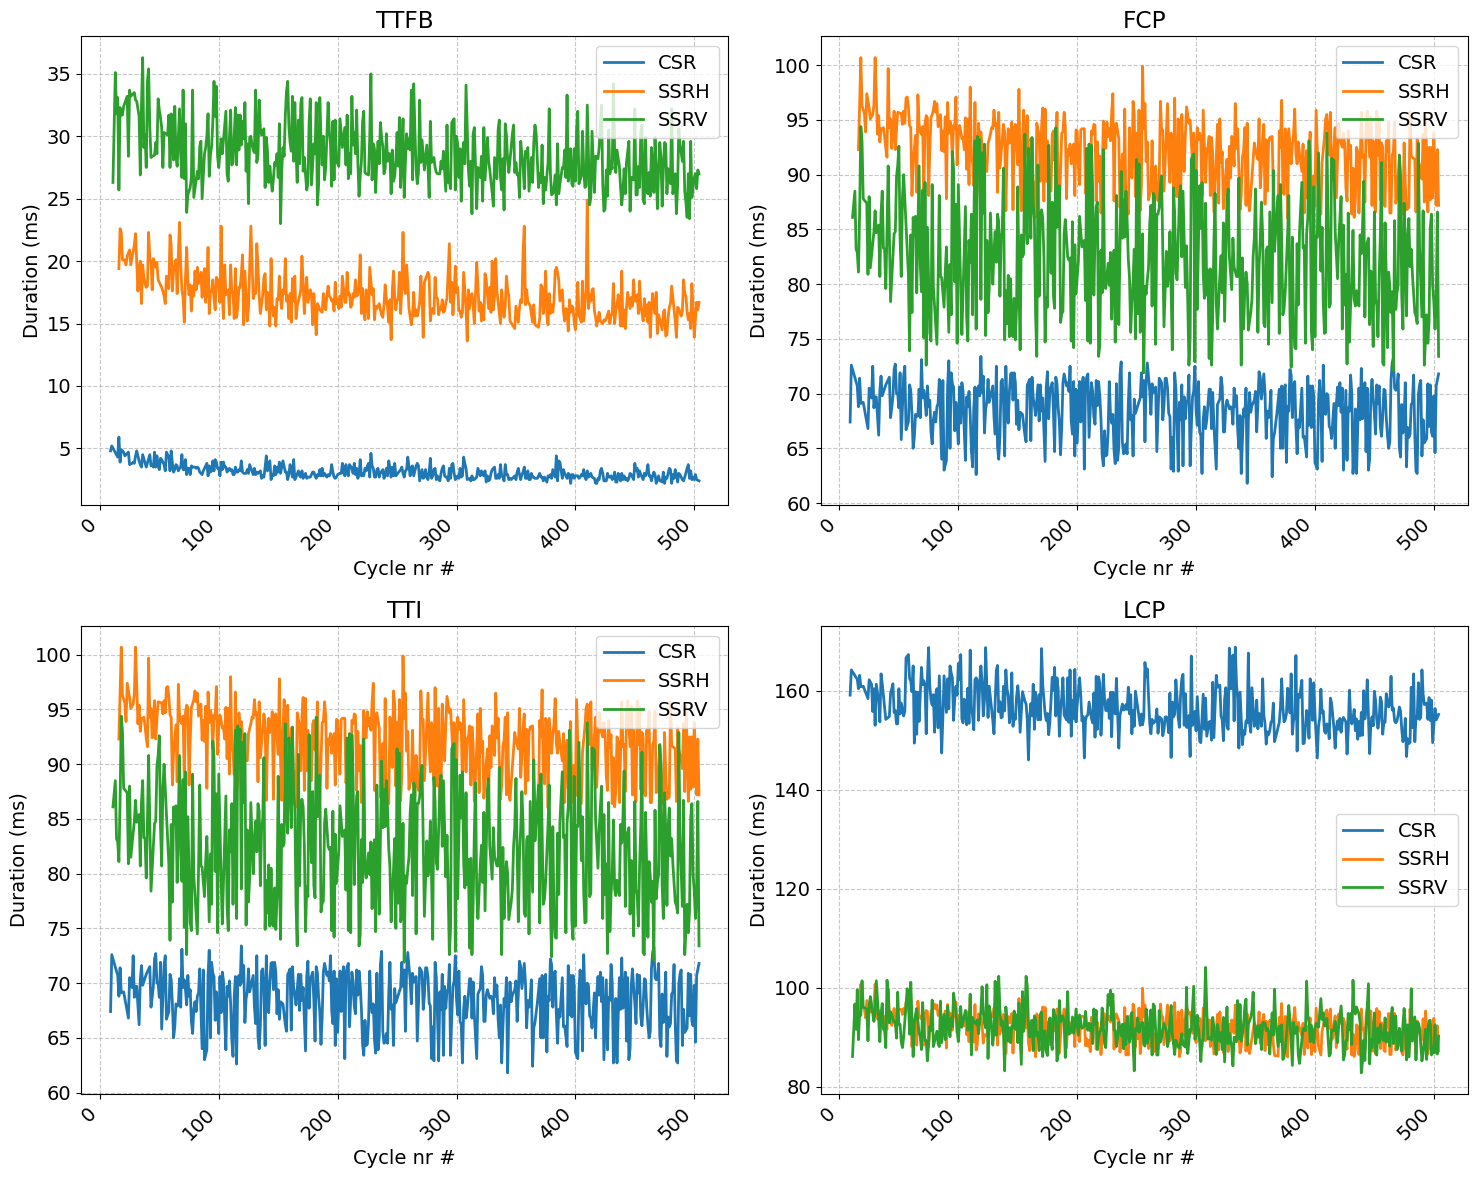

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(target_features):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

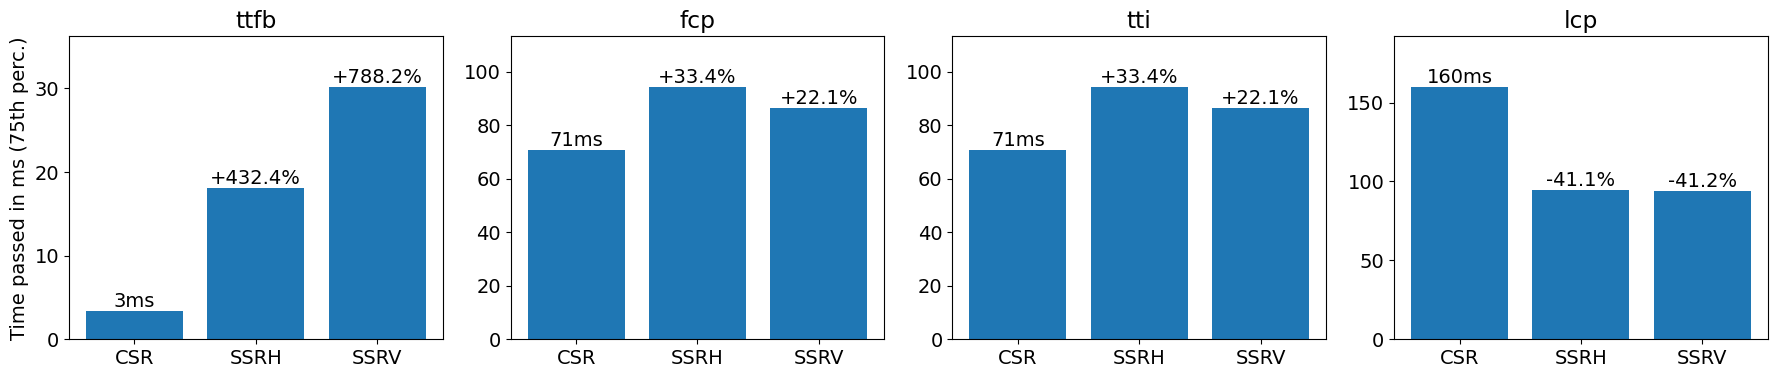

In [8]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(18, 4))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for i, bar in enumerate(bars):
        percentage = ((bar.get_height() / baseline) - 1) * 100
        label = f'{int(round(bar.get_height(), 0))}ms' if (i == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., bar.get_height(), label, ha='center', va='bottom')
    
    axes[idx].set_title(feature)
    if idx == 0:
        axes[idx].set_ylabel('Time passed in ms (75th perc.)')

plt.tight_layout()
plt.show()

## THROTTLED Comparison


In [9]:
target_features = ['tbt','ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}results-csr-sd-throttled.csv', sep=',').iloc[5:],
  "SSRH": pd.read_csv(f'{path}results-ssrh-sd-throttled.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}results-ssrv-sd-throttled.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Statistical significance (CSR vs SSRH)

A mann-whitney U-test to discover the statistical significance of the results.

In [10]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRH"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRH"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRH"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.683e-165,206.20,176.30,29.60,30.20,8.049e-165,True
1,fcp,greater,2.918e-165,1033.20,973.90,57.83,61.52,8.753e-165,True
2,lcp,less,2.918e-165,1046.43,5938.93,-4894.47,-4889.20,8.753e-165,True


### Statistical significance (CSR vs SSRV)

A mann-whitney U-test to discover the statistical significance of the results.

In [11]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRV"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRV"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRV"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.607e-165,226.60,176.30,50.00,50.50,7.821e-165,True
1,fcp,greater,1.00000,259.83,973.90,-715.00,-711.80,1.00000,False
2,lcp,less,2.923e-165,1047.60,5938.93,-4893.30,-4887.90,8.770e-165,True


### Comparison of the different metrics

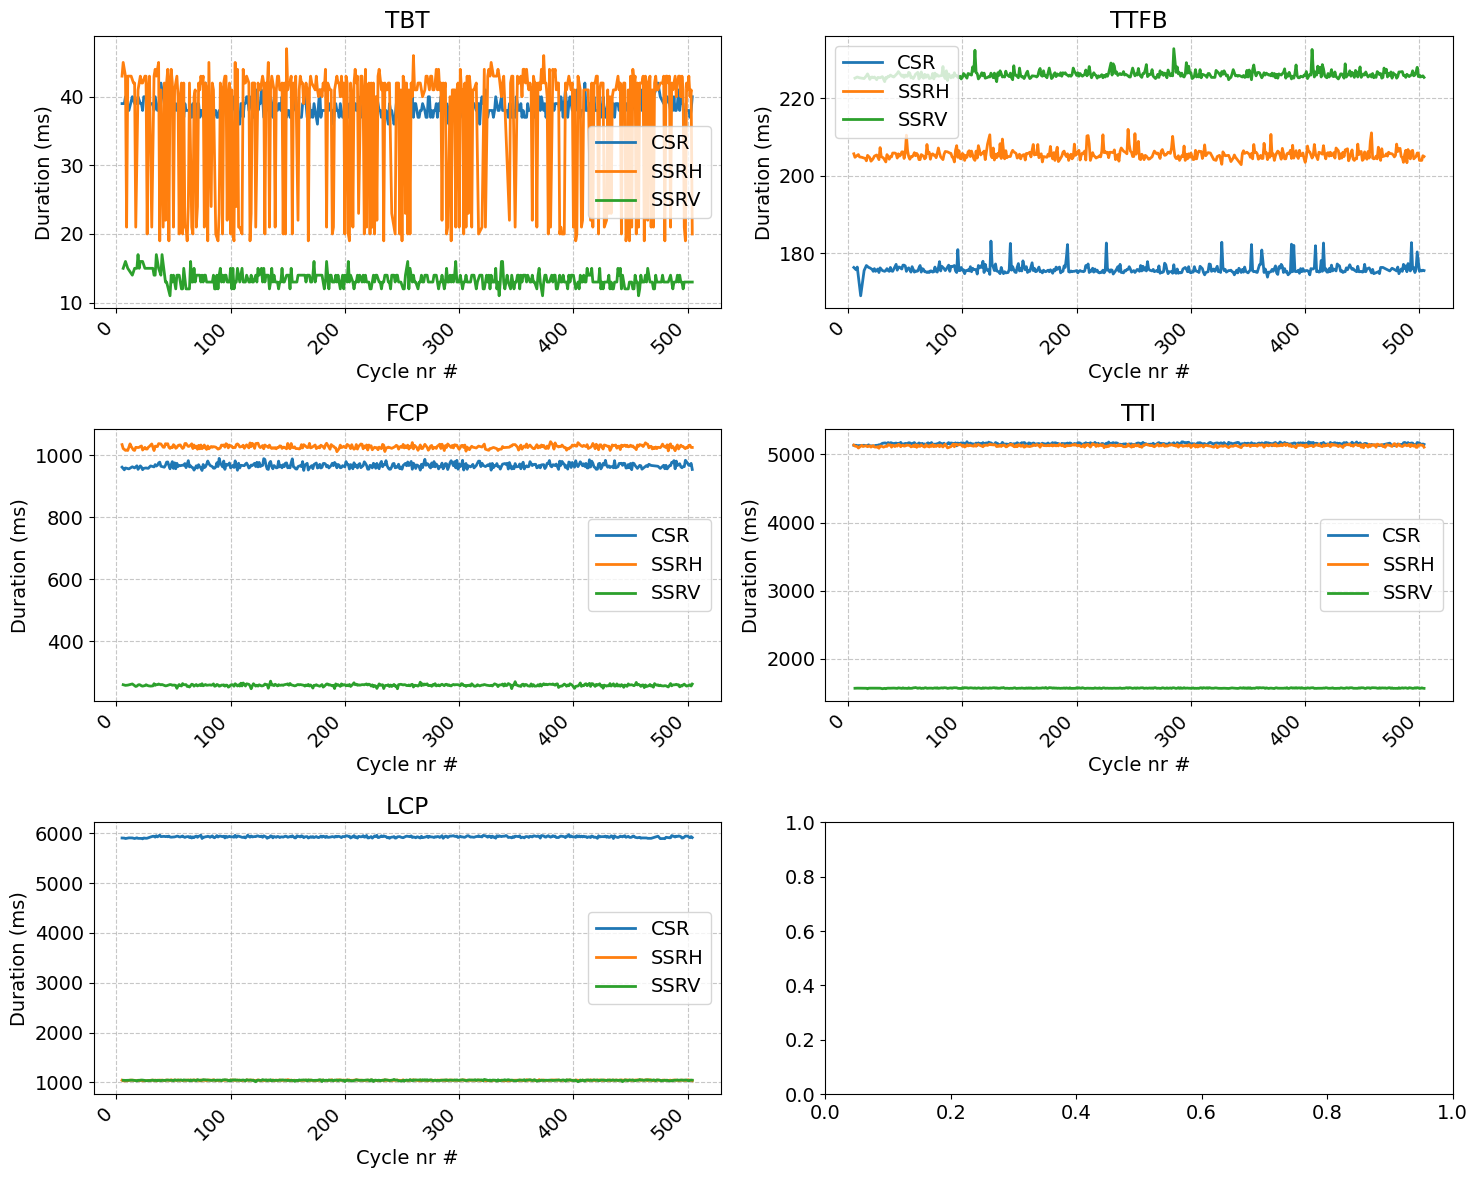

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(target_features):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

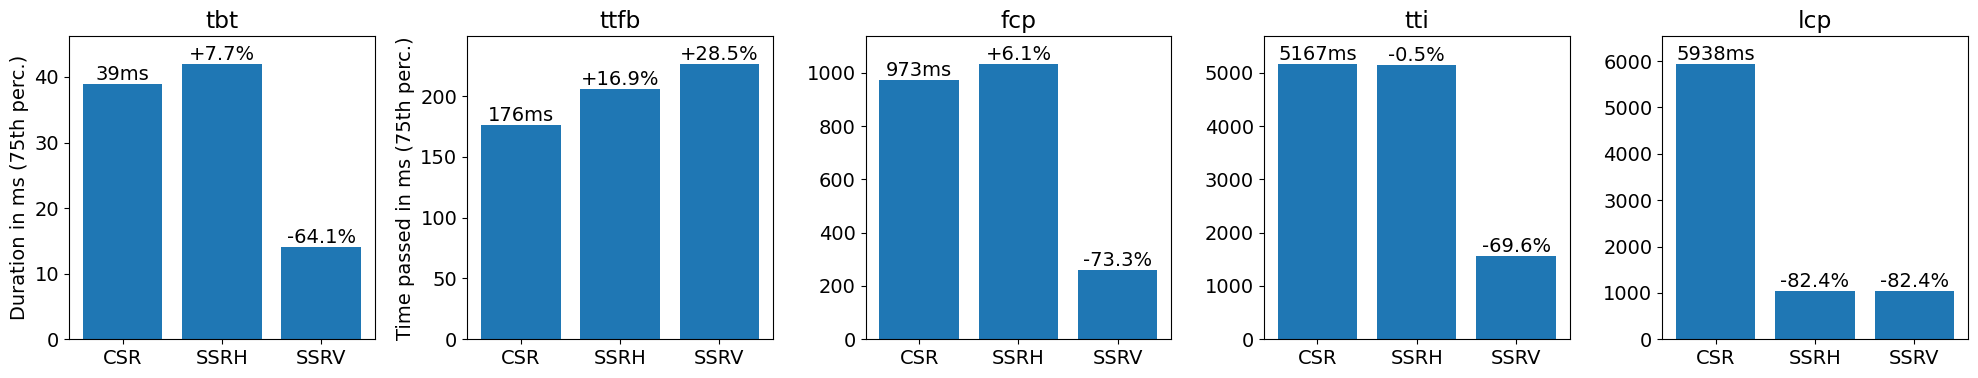

In [13]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(20, 4))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.10)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        percentage = ((height / baseline) - 1) * 100
        label = f'{int(round(height, 0))}ms' if (i == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., height, label, ha='center', va='bottom')
    
    axes[idx].set_title(feature)
    if idx == 0:
        axes[idx].set_ylabel('Duration in ms (75th perc.)')
    if idx == 1:
        axes[idx].set_ylabel('Time passed in ms (75th perc.)')

plt.tight_layout()
plt.show()

## HEAVY THROTTLED Comparison

In [14]:
target_features = ['tbt','ttfb', 'fcp', 'tti', 'lcp']

dirty_dfs =	{
  "CSR": pd.read_csv(f'{path}results-csr-sd-throttled-heavy.csv', sep=',').iloc[5:],
  "SSRH": pd.read_csv(f'{path}results-ssrh-sd-throttled-heavy.csv', sep=',').iloc[5:],
  "SSRV": pd.read_csv(f'{path}results-ssrv-sd-throttled-heavy.csv', sep=',').iloc[5:],
}

masks = {}
dfs = {}

for name, df in dirty_dfs.items():
    mask = detect_outliers(df, target_features)
    masks[name] = mask
    dfs[name] = df[mask].copy()

### Statistical significance (CSR vs SSRH)

A mann-whitney U-test to discover the statistical significance of the results.

In [15]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRH"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRH"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRH"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.846e-165,207.20,178.10,28.70,29.40,8.537e-165,True
1,fcp,greater,7.037e-165,1107.40,1063.90,37.52,45.50,2.111e-164,True
2,lcp,less,2.926e-165,1133.42,6410.30,-5280.60,-5273.55,8.777e-165,True


### Statistical significance (CSR vs SSRV)

A mann-whitney U-test to discover the statistical significance of the results.

In [16]:
hypothesis = {
    'ttfb': 'greater', 
    'fcp': 'greater', 
    'lcp': 'less'
}

results = pd.DataFrame([
    [metric, 
     hyp, 
     stats.mannwhitneyu(dirty_dfs["SSRV"][metric], 
                        dirty_dfs["CSR"][metric],
                        alternative=hyp)[1],
     dirty_dfs["SSRV"][metric].quantile(0.75),
     dirty_dfs["CSR"][metric].quantile(0.75),
     *bootstrap_ci(dirty_dfs["SSRV"][metric], 
                           dirty_dfs["CSR"][metric])]
    for metric, hyp in hypothesis.items()
], columns=['metric', 'hypothesis', 'p_value',  'ssrh_p75','csr_p75', 'ci_lower', 'ci_upper'])

results['adjusted_p'] = multipletests(results['p_value'], method='bonferroni')[1]
results['significant'] = results['adjusted_p'] < 0.01 

compact_format = lambda x: '%.3e' % x if x < 0.00001 else '%.5f' % x
results['p_value'] = results['p_value'].apply(compact_format)
results['adjusted_p'] = results['adjusted_p'].apply(compact_format)

results

,metric,hypothesis,p_value,ssrh_p75,csr_p75,ci_lower,ci_upper,adjusted_p,significant
0,ttfb,greater,2.790e-165,227.60,178.10,49.10,49.80,8.369e-165,True
1,fcp,greater,1.00000,342.52,1063.90,-727.18,-718.55,1.00000,False
2,lcp,less,2.926e-165,1091.12,6410.30,-5321.70,-5315.72,8.778e-165,True


### Comparing the different metrics


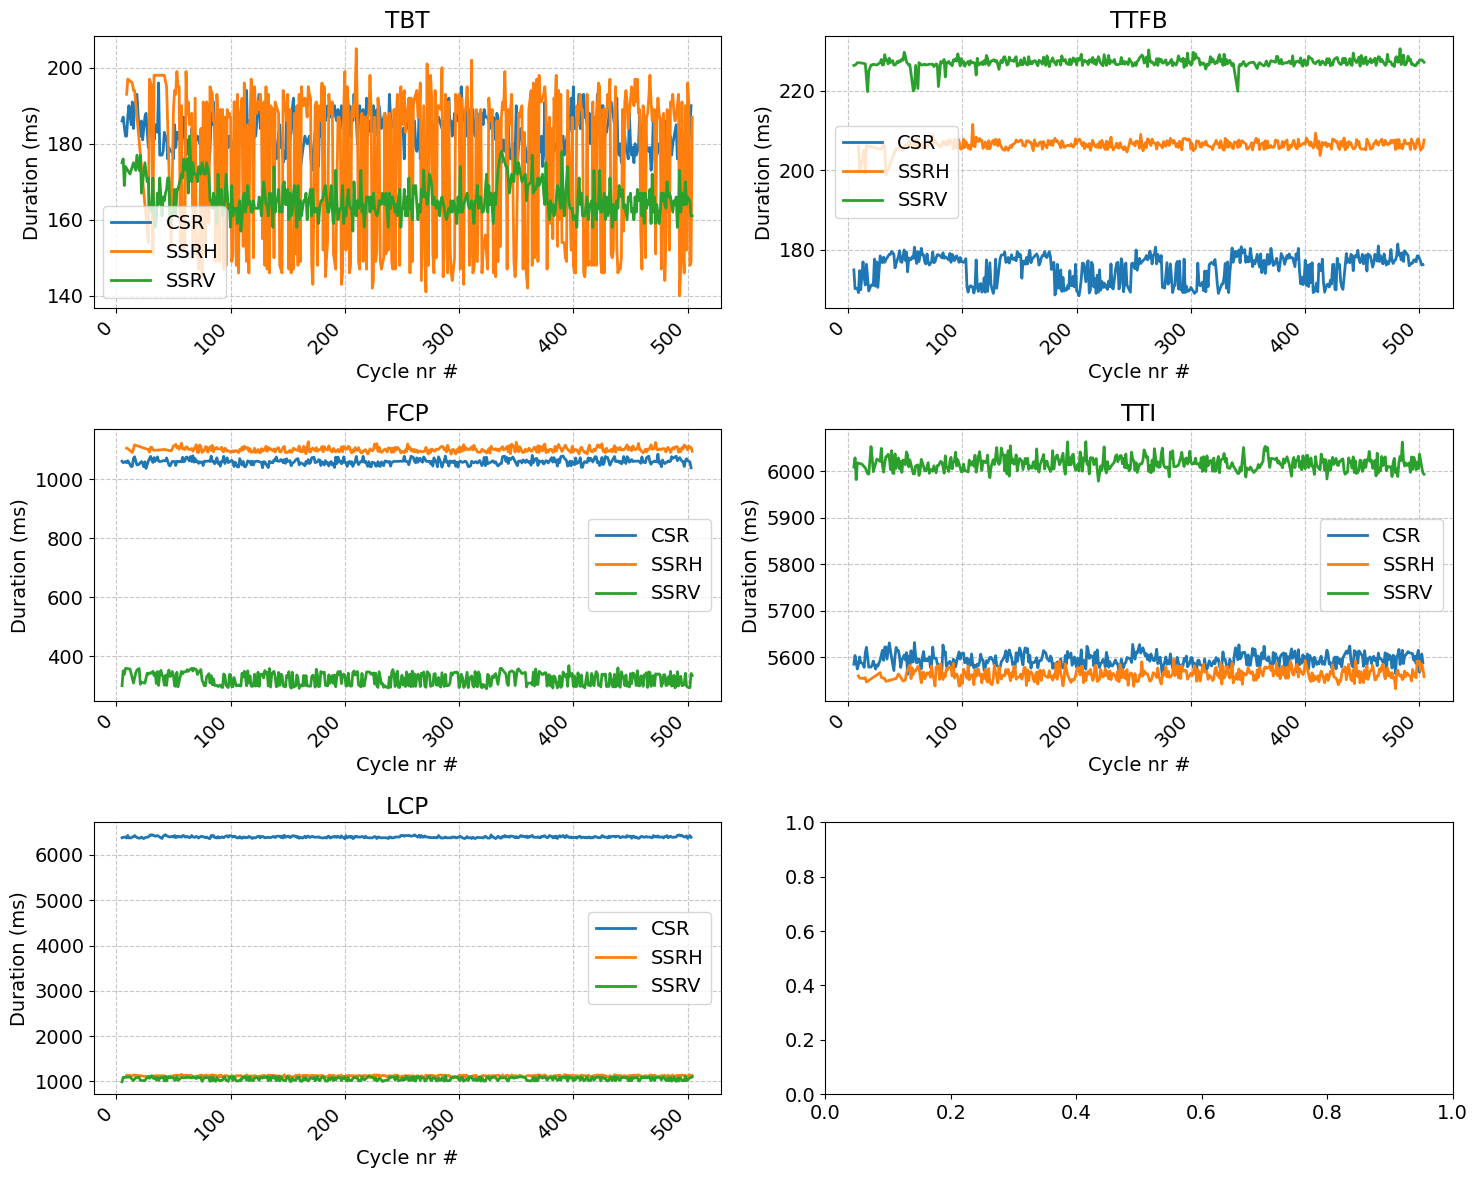

In [17]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(target_features):
    ax = axes[idx]
    
    for name, df in dfs.items():
        ax.plot(df[feature], 
                label=name, linewidth=2)
    
    ax.set_title(feature.upper())
    ax.set_xlabel('Cycle nr #')
    ax.set_ylabel('Duration (ms)')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

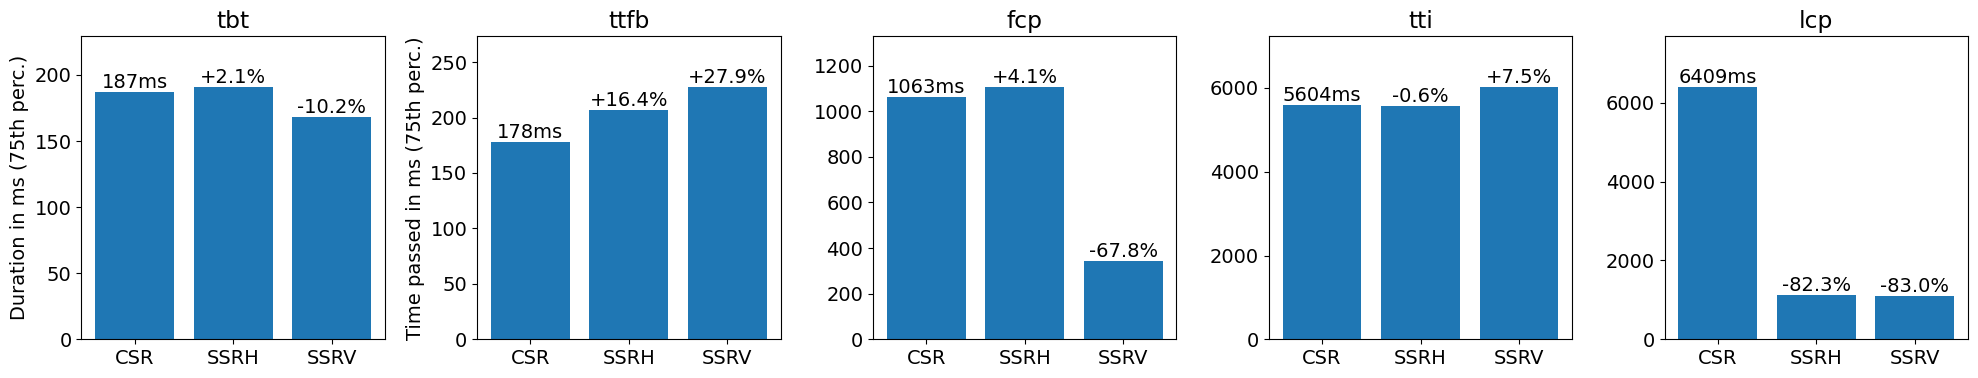

In [18]:
fig, axes = plt.subplots(ncols=len(target_features), figsize=(20, 4))
plt.subplots_adjust(hspace=0.3, wspace=0.3, top=0.95, bottom=0.05)

for idx, feature in enumerate(target_features):
    percentiles = {d: dfs[d][feature].quantile(0.75) for d in dfs}
    bars = axes[idx].bar(percentiles.keys(), percentiles.values())
    baseline = list(percentiles.values())[0]

    max_height = max(percentiles.values())
    axes[idx].set_ylim(0, max_height * 1.2)
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        percentage = ((height / baseline) - 1) * 100
        label = f'{int(round(height, 0))}ms' if (i == 0) else f'{percentage:+.1f}%'
        axes[idx].text(bar.get_x() + bar.get_width()/2., height, label, ha='center', va='bottom')
    
    axes[idx].set_title(feature)
    if idx == 0:
        axes[idx].set_ylabel('Duration in ms (75th perc.)')
    if idx == 1:
        axes[idx].set_ylabel('Time passed in ms (75th perc.)')

plt.tight_layout()
plt.show()